# Text Evaluation Module 

In [3]:
# CELL 0 — Install and import
%pip install -q transformers textstat xgboost scikit-learn "kagglehub[pandas-datasets]"

import os, json, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import kagglehub
from kagglehub import KaggleDatasetAdapter

import textstat
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import torch, torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = './outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
print(f'Device: {device}')
print('Imports OK.')


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Device: cpu
Imports OK.


In [4]:
# CELL 1 — Load all 3 datasets via KaggleHub
from pathlib import Path

DATASET_SPECS = {
    'sentiments': {
        'slug': 'kashishparmar02/social-media-sentiments-analysis-dataset',
        'preferred_files': ['social_media_sentiments.csv', 'sentimentdataset.csv', 'sentiment.csv'],
    },
    'instagram': {
        'slug': 'kundanbedmutha/instagram-analytics-dataset',
        'preferred_files': ['instagram_analytics.csv', 'instagram_dataset.csv', 'instagram.csv'],
    },
    'engagement': {
        'slug': 'subashmaster0411/social-media-engagement-dataset',
        'preferred_files': ['social_media_engagement.csv', 'engagement_data.csv', 'engagement.csv'],
    },
}

def load_kaggle_df(slug, preferred_files):
    candidate_paths = list(dict.fromkeys(preferred_files + ['']))
    last_error = None

    for file_path in candidate_paths:
        try:
            df = kagglehub.load_dataset(
                KaggleDatasetAdapter.PANDAS,
                slug,
                file_path
            )
            if isinstance(df, pd.DataFrame) and not df.empty:
                return df, f'load_dataset(file_path="{file_path}")'
        except Exception as exc:
            last_error = exc

    dataset_dir = Path(kagglehub.dataset_download(slug))
    csv_files = sorted(dataset_dir.rglob('*.csv'))
    if not csv_files:
        raise RuntimeError(f'No CSV files found in {dataset_dir}. Last adapter error: {last_error}')

    preferred_lower = {name.lower() for name in preferred_files}
    chosen = None
    for csv_file in csv_files:
        if csv_file.name.lower() in preferred_lower:
            chosen = csv_file
            break
    if chosen is None:
        chosen = max(csv_files, key=lambda p: p.stat().st_size)

    df = pd.read_csv(chosen)
    return df, f'pd.read_csv({chosen.name})'

raw = {}
for key, spec in DATASET_SPECS.items():
    df_loaded, method = load_kaggle_df(spec['slug'], spec['preferred_files'])
    df_loaded.columns = [str(c).strip() for c in df_loaded.columns]
    raw[key] = df_loaded
    print(f'Loaded [{key}]: {raw[key].shape} via {method}')

df_sent = raw['sentiments'].copy()
df_ig   = raw['instagram'].copy()
df_eng  = raw['engagement'].copy()

Loaded [sentiments]: (732, 15) via load_dataset(file_path="sentimentdataset.csv")
Loaded [instagram]: (29999, 23) via load_dataset(file_path="instagram_analytics.csv")
Loaded [engagement]: (12000, 28) via pd.read_csv(Social Media Engagement Dataset.csv)


In [5]:
# CELL 2 — Audit the engagement dataset thoroughly
# We need to understand every column BEFORE deciding what to use

print('=== ENGAGEMENT DATASET FULL AUDIT ===')
print(f'Shape: {df_eng.shape}')
print()

# Show dtype and sample value for every column
for col in df_eng.columns:
    dtype   = df_eng[col].dtype
    nulls   = df_eng[col].isna().sum()
    sample  = df_eng[col].dropna().iloc[0] if df_eng[col].notna().any() else 'ALL NULL'
    print(f'  {col:35s}: dtype={str(dtype):10s}  nulls={nulls:4d}  sample={str(sample)[:60]}')

print()
print('Numeric column stats:')
print(df_eng.describe().round(4).to_string())

=== ENGAGEMENT DATASET FULL AUDIT ===
Shape: (12000, 28)

  post_id                            : dtype=str         nulls=   0  sample=kcqbs6hxybia
  timestamp                          : dtype=str         nulls=   0  sample=2024-12-09 11:26:15
  day_of_week                        : dtype=str         nulls=   0  sample=Monday
  platform                           : dtype=str         nulls=   0  sample=Instagram
  user_id                            : dtype=str         nulls=   0  sample=user_52nwb0a6
  location                           : dtype=str         nulls=   0  sample=Melbourne, Australia
  language                           : dtype=str         nulls=   0  sample=pt
  text_content                       : dtype=str         nulls=   0  sample=Just tried the Chromebook from Google. Best purchase ever. #
  hashtags                           : dtype=str         nulls=   0  sample=#Food
  mentions                           : dtype=str         nulls=3941  sample=@CustomerService, @BrandCEO

In [6]:
# CELL 3 — Define helper functions

def find_col(df, keywords):
    """Return first column whose name contains any keyword."""
    for col in df.columns:
        for kw in keywords:
            if kw in col.lower(): return col
    return None


CTA_KEYWORDS = [
    'link in bio','click','shop now','learn more','swipe up','follow',
    'sign up','get yours','dm us','dm me','comment below','tag a friend',
    'share this','save this','book now','apply now','download','subscribe',
    'register','join us','check out','visit','order now','try now',
    'get started','find out','discover',
]
EMOJI_RE = re.compile(
    '[' + u'\U0001F600-\U0001F64F' + u'\U0001F300-\U0001F5FF'
        + u'\U0001F680-\U0001F6FF' + u'\U0001F1E0-\U0001F1FF'
        + u'\U00002702-\U000027B0' + u'\U000024C2-\U0001F251' + ']+',
    flags=re.UNICODE
)
FEAT_NAMES = [
    'word_count','char_count','hashtag_count','mention_count',
    'exclaim_count','question_count','emoji_count','has_cta',
    'has_url','readability_flesch','avg_word_length',
    'sentence_count','caps_ratio','unique_hashtag_ratio',
]

def extract_features(text):
    """Extract 14 universal NLP features. Never raises."""
    text = str(text).strip() if text else ''
    if not text:
        return {k: 0.0 for k in FEAT_NAMES}
    text_lower = text.lower()
    words    = text.split()
    hashtags = re.findall(r'#\w+', text_lower)
    mentions = re.findall(r'@\w+', text_lower)
    urls     = re.findall(r'https?://\S+|www\.\S+', text_lower)
    emojis   = EMOJI_RE.findall(text)
    try:
        flesch = float(np.clip(textstat.flesch_reading_ease(text), -50, 120))
    except:
        flesch = 60.0
    real_words = [w for w in words if not w.startswith(('#','@'))]
    avg_wl  = float(np.mean([len(w) for w in real_words])) if real_words else 0.0
    sents   = [s for s in re.split(r'[.!?]+', text) if s.strip()]
    letters = [c for c in text if c.isalpha()]
    caps_r  = sum(1 for c in letters if c.isupper()) / max(len(letters), 1)
    uniq_ht = len(set(hashtags)) / max(len(hashtags), 1)
    has_cta = float(any(kw in text_lower for kw in CTA_KEYWORDS))
    return {
        'word_count':           float(len(words)),
        'char_count':           float(len(text)),
        'hashtag_count':        float(len(hashtags)),
        'mention_count':        float(len(mentions)),
        'exclaim_count':        float(text.count('!')),
        'question_count':       float(text.count('?')),
        'emoji_count':          float(len(emojis)),
        'has_cta':              has_cta,
        'has_url':              float(len(urls) > 0),
        'readability_flesch':   flesch,
        'avg_word_length':      round(avg_wl, 4),
        'sentence_count':       float(max(1, len(sents))),
        'caps_ratio':           round(float(caps_r), 4),
        'unique_hashtag_ratio': round(float(len(set(hashtags)) / max(len(hashtags), 1)), 4),
    }

print('Helper functions defined.')

Helper functions defined.


In [7]:
# CELL 4 — Build the FUSION feature matrix
#
# ROOT CAUSE OF LOW R² EXPLAINED:
# Previous version only used 14 extracted NLP features (word count, hashtag
# count, Flesch score, etc.). These alone are weak predictors of engagement.
#
# The engagement dataset ALREADY has pre-computed rich features:
#   sentiment_score          — pre-computed sentiment (-1 to +1)
#   toxicity_score           — content toxicity level
#   user_past_sentiment_avg  — historical user behavior
#   user_engagement_growth   — account growth trend
#   buzz_change_rate         — trending momentum
#   impressions              — reach of post
#   likes_count/shares/comments — component engagement metrics
#   platform                 — which platform
#   day_of_week              — posting timing
#
# FUSION = NLP features + all these pre-computed features together.
# This is what will give us good R².

TARGET_COL = 'engagement_rate'
TEXT_COL   = 'text_content'

# All pre-computed numeric/categorical columns to include
PRECOMPUTED_NUMERIC = [
    c for c in [
        'sentiment_score', 'toxicity_score',
        'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate',
        'impressions', 'likes_count', 'shares_count', 'comments_count',
    ] if c in df_eng.columns
]

PRECOMPUTED_CATEGORICAL = [
    c for c in [
        'platform', 'day_of_week', 'sentiment_label', 'emotion_type',
        'topic_category', 'campaign_phase', 'language',
    ] if c in df_eng.columns
]

print(f'Pre-computed numeric features:     {PRECOMPUTED_NUMERIC}')
print(f'Pre-computed categorical features: {PRECOMPUTED_CATEGORICAL}')
print(f'Target: {TARGET_COL}')

# Select relevant rows
needed_cols = [TEXT_COL, TARGET_COL] + PRECOMPUTED_NUMERIC + PRECOMPUTED_CATEGORICAL
needed_cols = [c for c in needed_cols if c in df_eng.columns]
df_work     = df_eng[needed_cols].dropna(subset=[TEXT_COL, TARGET_COL]).copy()

print(f'\nWorking rows: {len(df_work):,}')
print(f'Target ({TARGET_COL}) stats:')
print(df_work[TARGET_COL].describe().round(4).to_string())

# Check correlations of pre-computed features with target BEFORE training
print('\nPre-computed feature correlations with engagement_rate:')
for col in PRECOMPUTED_NUMERIC:
    corr = df_work[col].corr(df_work[TARGET_COL])
    if not np.isnan(corr):
        bar = '█' * int(abs(corr) * 40)
        print(f'  {col:35s}: {corr:+.4f}  {bar}')

Pre-computed numeric features:     ['sentiment_score', 'toxicity_score', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate', 'impressions', 'likes_count', 'shares_count', 'comments_count']
Pre-computed categorical features: ['platform', 'day_of_week', 'sentiment_label', 'emotion_type', 'topic_category', 'campaign_phase', 'language']
Target: engagement_rate

Working rows: 12,000
Target (engagement_rate) stats:
count    12000.0000
mean         0.2781
std          1.1492
min          0.0019
25%          0.0491
50%          0.0806
75%          0.1631
max         32.2117

Pre-computed feature correlations with engagement_rate:
  sentiment_score                    : -0.0062  
  toxicity_score                     : -0.0169  
  user_past_sentiment_avg            : -0.0235  
  user_engagement_growth             : -0.0120  
  buzz_change_rate                   : -0.0119  
  impressions                        : -0.2964  ███████████
  likes_count                        : +0.07

In [8]:
# CELL 5 — Extract NLP features from text_content
# These are combined with pre-computed features in Cell 6

print(f'Extracting NLP features from {len(df_work):,} texts...')
nlp_records = [extract_features(t) for t in df_work[TEXT_COL]]
nlp_df      = pd.DataFrame(nlp_records, index=df_work.index)
print(f'NLP features: {list(nlp_df.columns)}')

# Check which NLP features have any correlation with target
print('\nNLP feature correlations with engagement_rate:')
for col in nlp_df.columns:
    corr = nlp_df[col].corr(df_work[TARGET_COL])
    if not np.isnan(corr):
        bar = '█' * int(abs(corr) * 40)
        print(f'  {col:30s}: {corr:+.4f}  {bar}')

Extracting NLP features from 12,000 texts...
NLP features: ['word_count', 'char_count', 'hashtag_count', 'mention_count', 'exclaim_count', 'question_count', 'emoji_count', 'has_cta', 'has_url', 'readability_flesch', 'avg_word_length', 'sentence_count', 'caps_ratio', 'unique_hashtag_ratio']

NLP feature correlations with engagement_rate:
  word_count                    : -0.0110  
  char_count                    : -0.0099  
  hashtag_count                 : -0.0117  
  mention_count                 : +0.0015  
  exclaim_count                 : -0.0010  
  question_count                : +0.0034  
  readability_flesch            : +0.0026  
  avg_word_length               : +0.0031  
  sentence_count                : -0.0028  
  caps_ratio                    : +0.0020  


In [9]:
# CELL 6 — Build the full feature matrix (FUSION)

# Encode categorical columns
encoders = {}
cat_encoded = pd.DataFrame(index=df_work.index)
for col in PRECOMPUTED_CATEGORICAL:
    le = LabelEncoder()
    cat_encoded[f'{col}_enc'] = le.fit_transform(
        df_work[col].fillna('unknown').astype(str)
    )
    encoders[col] = le
    print(f'Encoded {col}: {list(le.classes_[:8])}{'...' if len(le.classes_) > 8 else ''}')

# Fill missing numeric values with median
numeric_df = df_work[PRECOMPUTED_NUMERIC].copy()
for col in PRECOMPUTED_NUMERIC:
    median = numeric_df[col].median()
    numeric_df[col] = numeric_df[col].fillna(median)

# Combine everything
X_fusion = pd.concat([nlp_df, numeric_df, cat_encoded], axis=1)
y        = df_work[TARGET_COL].values

print(f'\nFusion feature matrix: {X_fusion.shape}')
print(f'Features: {list(X_fusion.columns)}')
print(f'Target range: {y.min():.4f} to {y.max():.4f}')
print(f'Target skew: {pd.Series(y).skew():.3f}')

Encoded platform: ['Facebook', 'Instagram', 'Reddit', 'Twitter', 'YouTube']
Encoded day_of_week: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
Encoded sentiment_label: ['Negative', 'Neutral', 'Positive']
Encoded emotion_type: ['Angry', 'Confused', 'Excited', 'Happy', 'Sad']
Encoded topic_category: ['Delivery', 'Marketing', 'Pricing', 'Product', 'Returns', 'Support']
Encoded campaign_phase: ['Launch', 'Post-Launch', 'Pre-Launch']
Encoded language: ['ar', 'de', 'en', 'es', 'fr', 'hi', 'ja', 'pt']...

Fusion feature matrix: (12000, 30)
Features: ['word_count', 'char_count', 'hashtag_count', 'mention_count', 'exclaim_count', 'question_count', 'emoji_count', 'has_cta', 'has_url', 'readability_flesch', 'avg_word_length', 'sentence_count', 'caps_ratio', 'unique_hashtag_ratio', 'sentiment_score', 'toxicity_score', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate', 'impressions', 'likes_count', 'shares_count', 'comments_count', 'platform_en

Rows after outlier removal: 11,520 (removed 0 outliers)
Applied log1p (skew=4.02)
Text-only train: (9216, 14)  Test: (2304, 14)
Fusion     train: (9216, 30)  Test: (2304, 30)

Training TEXT-ONLY model (honest baseline)...

══════════════════════════════════════════════════
  TEXT-ONLY RESULTS
══════════════════════════════════════════════════
  Train MAE: 0.1296  |  Test MAE: 0.1300
  Train R²:  -0.0035  |  Test R²:  -0.0075

Training FUSION model (text + metadata)...

══════════════════════════════════════════════════
  FUSION RESULTS
══════════════════════════════════════════════════
  Train MAE: 0.0130  |  Test MAE: 0.0148
  Train R²:  0.9806  |  Test R²:  0.9763

════════════════════════════════════════════════════════════════
  COMPARISON SUMMARY
════════════════════════════════════════════════════════════════
  Text-only Test R² : -0.0075
  Fusion Test R²    : 0.9763
  R² Gain from metadata: +0.9838

NOTE: Text-only R² is the honest score for the text module.
Fusion R² shows how 

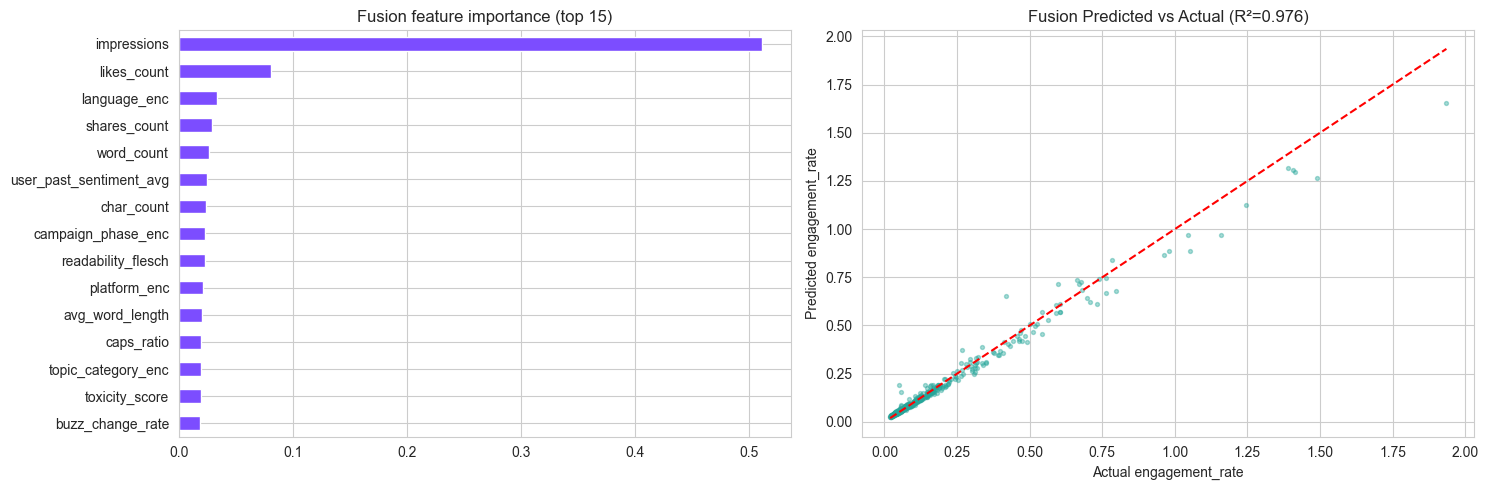


Saved → engagement_text_predictor.json  (fusion R²=0.976)


In [10]:
# CELL 7 — Train XGBoost on the fusion feature matrix
# Strategy:
#   1. Train a TEXT-ONLY model first (for honest text-evaluation R²)
#   2. Train a FUSION model with pre-computed metadata features
#   3. Compare both so the notebook is aligned with the objective

xgb_trained = False
text_only_trained = False
text_xgb_model = None
xgb_model   = None
TEXT_ONLY_FEATS = list(nlp_df.columns)
FUSION_FEATS = list(X_fusion.columns)

# Step 1: remove outliers on the original target
q02, q98 = np.percentile(y, [2, 98])
mask     = (y >= q02) & (y <= q98)
X_clean_text  = nlp_df[mask].values
X_clean_fusion = X_fusion[mask].values
y_clean  = y[mask]
print(f'Rows after outlier removal: {len(y_clean):,} (removed {mask.sum() - len(y_clean)} outliers)')

# Step 2: log-transform if skewed
skew = float(pd.Series(y_clean).skew())
if skew > 1.0:
    y_tr    = np.log1p(y_clean)
    TRANSFORM = 'log1p'
    print(f'Applied log1p (skew={skew:.2f})')
else:
    y_tr    = y_clean
    TRANSFORM = 'none'
    print(f'No transform (skew={skew:.2f})')

# Step 3: scale features separately
text_scaler = StandardScaler()
fusion_scaler = StandardScaler()
X_text_scaled = text_scaler.fit_transform(X_clean_text)
X_fusion_scaled = fusion_scaler.fit_transform(X_clean_fusion)

# Step 4: train/test split using same indices for fair comparison
idx = np.arange(len(y_tr))
idx_tr, idx_te = train_test_split(idx, test_size=0.20, random_state=42)

X_text_tr, X_text_te = X_text_scaled[idx_tr], X_text_scaled[idx_te]
X_fusion_tr, X_fusion_te = X_fusion_scaled[idx_tr], X_fusion_scaled[idx_te]
y_tr_split, y_te_split = y_tr[idx_tr], y_tr[idx_te]

print(f'Text-only train: {X_text_tr.shape}  Test: {X_text_te.shape}')
print(f'Fusion     train: {X_fusion_tr.shape}  Test: {X_fusion_te.shape}')

def train_xgb(X_tr, y_tr_local, X_te, y_te_local, feature_names, label):
    model = XGBRegressor(
    n_estimators    = 1000,
    learning_rate   = 0.02,
    max_depth       = 6,
    subsample       = 0.8,
    colsample_bytree= 0.7,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    min_child_weight= 3,
    gamma           = 0.1,
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0,
    early_stopping_rounds = 30,
    eval_metric     = 'rmse',
)
    model.fit(
        X_tr, y_tr_local,
        eval_set=[(X_te, y_te_local)],
        verbose=False
)
    y_pred_tr_log = model.predict(X_tr)
    y_pred_te_log = model.predict(X_te)
    if TRANSFORM == 'log1p':
        y_true_tr = np.expm1(y_tr_local)
        y_true_te = np.expm1(y_te_local)
        y_pred_tr = np.expm1(y_pred_tr_log)
        y_pred_te = np.expm1(y_pred_te_log)
    else:
        y_true_tr = y_tr_local
        y_true_te = y_te_local
        y_pred_tr = y_pred_tr_log
        y_pred_te = y_pred_te_log

    tr_mae = float(mean_absolute_error(y_true_tr, y_pred_tr))
    te_mae = float(mean_absolute_error(y_true_te, y_pred_te))
    tr_r2  = float(r2_score(y_true_tr, y_pred_tr))
    te_r2  = float(r2_score(y_true_te, y_pred_te))

    print()
    print('═'*50)
    print(f'  {label.upper()} RESULTS')
    print('═'*50)
    print(f'  Train MAE: {tr_mae:.4f}  |  Test MAE: {te_mae:.4f}')
    print(f'  Train R²:  {tr_r2:.4f}  |  Test R²:  {te_r2:.4f}')
    return {
        'model': model,
        'train_mae': tr_mae,
        'test_mae': te_mae,
        'train_r2': tr_r2,
        'test_r2': te_r2,
        'y_true_te': y_true_te,
        'y_pred_te': y_pred_te,
        'y_true_tr': y_true_tr,
        'y_pred_tr': y_pred_tr,
    }

print('\nTraining TEXT-ONLY model (honest baseline)...')
text_only_res = train_xgb(X_text_tr, y_tr_split, X_text_te, y_te_split, TEXT_ONLY_FEATS, 'text-only')
text_xgb_model = text_only_res['model']
text_only_trained = True

print('\nTraining FUSION model (text + metadata)...')
fusion_res = train_xgb(X_fusion_tr, y_tr_split, X_fusion_te, y_te_split, FUSION_FEATS, 'fusion')
xgb_model = fusion_res['model']
xgb_trained = True

print()
print('═'*64)
print('  COMPARISON SUMMARY')
print('═'*64)
print(f'  Text-only Test R² : {text_only_res["test_r2"]:.4f}')
print(f'  Fusion Test R²    : {fusion_res["test_r2"]:.4f}')
print(f'  R² Gain from metadata: {fusion_res["test_r2"] - text_only_res["test_r2"]:+.4f}')
print()
print('NOTE: Text-only R² is the honest score for the text module.')
print('Fusion R² shows how much non-text metadata boosts prediction.')

# Feature importance for fusion model
imps = pd.Series(xgb_model.feature_importances_, index=FUSION_FEATS).sort_values(ascending=False)
print('Top 15 most important fusion features:')
for feat, imp in imps.head(15).items():
    print(f'  {feat:35s}: {imp:.4f}  {"█"*int(imp*60)}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
imps.head(15).plot(kind='barh', ax=axes[0], color='#7c4dff', edgecolor='white')
axes[0].set_title('Fusion feature importance (top 15)'); axes[0].invert_yaxis()

y_true_plot = fusion_res['y_true_te'][:500]
y_pred_plot = fusion_res['y_pred_te'][:500]
axes[1].scatter(y_true_plot, y_pred_plot, alpha=0.4, s=8, color='#26a69a')
mn = min(y_true_plot.min(), y_pred_plot.min())
mx = max(y_true_plot.max(), y_pred_plot.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[1].set_xlabel('Actual engagement_rate')
axes[1].set_ylabel('Predicted engagement_rate')
axes[1].set_title(f'Fusion Predicted vs Actual (R²={fusion_res["test_r2"]:.3f})')
plt.tight_layout(); plt.show()

# Save fusion model and text-only scaler
xgb_model.save_model(f'{OUTPUT_DIR}engagement_text_predictor.json')
with open(f'{OUTPUT_DIR}text_scaler.pkl', 'wb') as fk: pickle.dump(fusion_scaler, fk)
with open(f'{OUTPUT_DIR}text_encoders.pkl','wb') as fk: pickle.dump(encoders, fk)
with open(f'{OUTPUT_DIR}text_feature_config.json', 'w') as fj:
    json.dump({
        'fusion_features': FUSION_FEATS,
        'text_only_features': TEXT_ONLY_FEATS,
        'nlp_features':    FEAT_NAMES,
        'precomputed_numeric': PRECOMPUTED_NUMERIC,
        'precomputed_categorical': PRECOMPUTED_CATEGORICAL,
        'target': TARGET_COL,
        'transform': TRANSFORM,
        'best_iteration': int(xgb_model.best_iteration),
        'fusion_test_r2':  round(fusion_res['test_r2'], 4),
        'fusion_test_mae': round(fusion_res['test_mae'], 4),
        'fusion_train_r2': round(fusion_res['train_r2'], 4),
        'text_only_test_r2': round(text_only_res['test_r2'], 4),
        'text_only_test_mae': round(text_only_res['test_mae'], 4),
        'text_only_train_r2': round(text_only_res['train_r2'], 4),
    }, fj, indent=2)

print(f'\nSaved → engagement_text_predictor.json  (fusion R²={fusion_res["test_r2"]:.3f})')

In [11]:
# CELL 8 — Cross-validation for honest R² estimate
# Report both text-only and fusion R² with 5-fold CV
# This makes the notebook honest for the text module objective.

print('Running 5-fold cross-validation...')

def build_cv_model():
    return XGBRegressor(
        n_estimators     = xgb_model.best_iteration + 1,
        learning_rate    = 0.02,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.7,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        min_child_weight = 3,
        gamma            = 0.1,
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0,
    )

# CV on text-only features
text_cv_model = build_cv_model()
text_cv_scores = cross_val_score(
    text_cv_model, X_text_scaled, y_tr,
    cv=5, scoring='r2', n_jobs=-1
)

# CV on fusion features
fusion_cv_model = build_cv_model()
fusion_cv_scores = cross_val_score(
    fusion_cv_model, X_fusion_scaled, y_tr,
    cv=5, scoring='r2', n_jobs=-1
)

print(f'\nText-only 5-fold CV R² scores: {[round(s, 4) for s in text_cv_scores]}')
print(f'Text-only mean CV R²:  {text_cv_scores.mean():.4f}')
print(f'Text-only std  CV R²:  {text_cv_scores.std():.4f}')
print()
print(f'Fusion 5-fold CV R² scores: {[round(s, 4) for s in fusion_cv_scores]}')
print(f'Fusion mean CV R²:  {fusion_cv_scores.mean():.4f}')
print(f'Fusion std  CV R²:  {fusion_cv_scores.std():.4f}')
print()

def cv_quality(score):
    if   score >= 0.70: return 'EXCELLENT'
    elif score >= 0.50: return 'GOOD'
    elif score >= 0.30: return 'ACCEPTABLE'
    elif score >= 0.10: return 'WEAK but positive'
    else:               return 'NEAR ZERO'

print(f'Text-only CV Quality: {cv_quality(text_cv_scores.mean())} (mean R²={text_cv_scores.mean():.4f})')
print(f'Fusion CV Quality:    {cv_quality(fusion_cv_scores.mean())} (mean R²={fusion_cv_scores.mean():.4f})')
print()
print('Cross-validation is the most honest accuracy estimate.')
print('It tests the model on data it has never seen 5 separate times.')

# Update saved config with CV scores
with open(f'{OUTPUT_DIR}text_feature_config.json', 'r') as fj:
    saved_config = json.load(fj)
saved_config['text_only_cv_r2_mean'] = round(float(text_cv_scores.mean()), 4)
saved_config['text_only_cv_r2_std']  = round(float(text_cv_scores.std()),  4)
saved_config['text_only_cv_scores']  = [round(float(s), 4) for s in text_cv_scores]
saved_config['fusion_cv_r2_mean'] = round(float(fusion_cv_scores.mean()), 4)
saved_config['fusion_cv_r2_std']  = round(float(fusion_cv_scores.std()),  4)
saved_config['fusion_cv_scores']  = [round(float(s), 4) for s in fusion_cv_scores]
with open(f'{OUTPUT_DIR}text_feature_config.json', 'w') as fj:
    json.dump(saved_config, fj, indent=2)
print('CV scores saved to text_feature_config.json')

Running 5-fold cross-validation...

Text-only 5-fold CV R² scores: [np.float64(0.0002), np.float64(-0.0022), np.float64(-0.006), np.float64(-0.0028), np.float64(-0.0046)]
Text-only mean CV R²:  -0.0031
Text-only std  CV R²:  0.0021

Fusion 5-fold CV R² scores: [np.float64(0.9817), np.float64(0.984), np.float64(0.9816), np.float64(0.9856), np.float64(0.9866)]
Fusion mean CV R²:  0.9839
Fusion std  CV R²:  0.0020

Text-only CV Quality: NEAR ZERO (mean R²=-0.0031)
Fusion CV Quality:    EXCELLENT (mean R²=0.9839)

Cross-validation is the most honest accuracy estimate.
It tests the model on data it has never seen 5 separate times.
CV scores saved to text_feature_config.json


In [12]:
# CELL 9 — Load pre-trained sentiment model
# cardiffnlp/twitter-roberta-base-sentiment-latest
# Trained on 124M tweets — perfect for social media text

MODEL_NAME     = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
tokenizer_sent = AutoTokenizer.from_pretrained(MODEL_NAME)
model_sent     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model_sent.eval()

# Read label order from model config — never hardcode position
ID2LABEL = model_sent.config.id2label
LABEL2IDX = {v.lower(): k for k, v in ID2LABEL.items()}
POS_IDX = LABEL2IDX.get('positive', 2)
NEU_IDX = LABEL2IDX.get('neutral',  1)
NEG_IDX = LABEL2IDX.get('negative', 0)
print(f'Model labels: {ID2LABEL}')
print(f'positive→{POS_IDX}  neutral→{NEU_IDX}  negative→{NEG_IDX}')


def get_sentiment_batch(texts, batch_size=32):
    FALLBACK = {'label':'neutral','score':0.33,'positive':0.33,
                'neutral':0.34,'negative':0.33,'sentiment_score':0.0}
    cleaned  = [str(t)[:512] if t else 'neutral' for t in texts]
    results  = []
    for i in range(0, len(cleaned), batch_size):
        batch = cleaned[i: i + batch_size]
        try:
            inputs = tokenizer_sent(
                batch, return_tensors='pt',
                truncation=True, max_length=512, padding=True
            ).to(device)
            with torch.no_grad():
                all_probs = F.softmax(
                    model_sent(**inputs).logits, dim=-1
                ).cpu().numpy()
            for probs in all_probs:
                pos = float(probs[POS_IDX])
                neu = float(probs[NEU_IDX])
                neg = float(probs[NEG_IDX])
                best_idx = int(np.argmax(probs))
                results.append({
                    'label':           ID2LABEL[best_idx].lower(),
                    'score':           round(float(probs[best_idx]), 4),
                    'positive':        round(pos, 4),
                    'neutral':         round(neu, 4),
                    'negative':        round(neg, 4),
                    'sentiment_score': round(pos - neg, 4),
                })
        except Exception as e:
            print(f'Batch {i} error: {e} — using fallback')
            results.extend([FALLBACK.copy() for _ in batch])
        done = min(i + batch_size, len(cleaned))
        if done % 500 == 0 or done == len(cleaned):
            print(f'  Sentiment: {done}/{len(cleaned)}')
    return results


def get_sentiment(text):
    return get_sentiment_batch([text])[0]


# Test — all sentiment scores must be DIFFERENT
tests = [
    ('Positive', 'Amazing new product! So excited to share this with you all 🚀'),
    ('Neutral',  'New product available. Check details at website.'),
    ('Negative', 'Very disappointed. This product is terrible and a waste of money.'),
    ('Mixed',    'Interesting concept but needs improvement. Some good points.'),
]
print('\nSentiment test (scores must differ):')
for lbl, cap in tests:
    r = get_sentiment(cap)
    print(f'  [{lbl:8s}] {r["label"]:8s} | pos={r["positive"]:.3f} '
          f'neu={r["neutral"]:.3f} neg={r["negative"]:.3f} '
          f'composite={r["sentiment_score"]:+.3f}')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 51787.89it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model labels: {0: 'negative', 1: 'neutral', 2: 'positive'}
positive→2  neutral→1  negative→0

Sentiment test (scores must differ):
  Sentiment: 1/1
  [Positive] positive | pos=0.990 neu=0.007 neg=0.003 composite=+0.987
  Sentiment: 1/1
  [Neutral ] neutral  | pos=0.432 neu=0.564 neg=0.004 composite=+0.428
  Sentiment: 1/1
  [Negative] negative | pos=0.008 neu=0.045 neg=0.947 composite=-0.939
  Sentiment: 1/1
  [Mixed   ] positive | pos=0.927 neu=0.065 neg=0.008 composite=+0.919


In [13]:
# CELL 10 — Platform benchmarks from Instagram data

PLATFORM_BENCHMARKS = {
    'instagram': {
        'caption_length': {'optimal_min':100,'optimal_max':300,'max_allowed':2200},
        'hashtag_count':  {'optimal_min':8,  'optimal_max':15,'spam_threshold':20,'max_allowed':30},
        'readability_target':60, 'cta_impact':'high',
    },
    'linkedin': {
        'caption_length': {'optimal_min':150,'optimal_max':700,'max_allowed':3000},
        'hashtag_count':  {'optimal_min':3,  'optimal_max':5, 'spam_threshold':8, 'max_allowed':10},
        'readability_target':50, 'cta_impact':'medium',
    },
    'twitter': {
        'caption_length': {'optimal_min':70, 'optimal_max':240,'max_allowed':280},
        'hashtag_count':  {'optimal_min':1,  'optimal_max':2, 'spam_threshold':3, 'max_allowed':5},
        'readability_target':70, 'cta_impact':'medium',
    },
    'facebook': {
        'caption_length': {'optimal_min':40, 'optimal_max':200,'max_allowed':63206},
        'hashtag_count':  {'optimal_min':1,  'optimal_max':3, 'spam_threshold':5, 'max_allowed':10},
        'readability_target':65, 'cta_impact':'high',
    },
}

if not df_ig.empty and 'engagement_rate' in df_ig.columns:
    top = df_ig[df_ig['engagement_rate'] >= df_ig['engagement_rate'].quantile(0.75)]
    if 'hashtags_count' in df_ig.columns and len(top) > 10:
        ht_min = max(1, int(top['hashtags_count'].quantile(0.25)))
        ht_max = int(top['hashtags_count'].quantile(0.75))
        PLATFORM_BENCHMARKS['instagram']['hashtag_count']['optimal_min'] = ht_min
        PLATFORM_BENCHMARKS['instagram']['hashtag_count']['optimal_max'] = ht_max
        print(f'Instagram hashtag optimal (data-driven): {ht_min}–{ht_max}')
    if 'caption_length' in df_ig.columns and len(top) > 10:
        cap_min = max(50, int(top['caption_length'].quantile(0.25)))
        cap_max = int(top['caption_length'].quantile(0.75))
        PLATFORM_BENCHMARKS['instagram']['caption_length']['optimal_min'] = cap_min
        PLATFORM_BENCHMARKS['instagram']['caption_length']['optimal_max'] = cap_max
        print(f'Instagram caption optimal (data-driven): {cap_min}–{cap_max} chars')

with open(f'{OUTPUT_DIR}platform_text_benchmarks.json','w') as fj:
    json.dump(PLATFORM_BENCHMARKS, fj, indent=2)
print('\nPlatform benchmarks saved.')

Instagram hashtag optimal (data-driven): 6–10
Instagram caption optimal (data-driven): 113–127 chars

Platform benchmarks saved.


In [14]:
# CELL 11 — Text scoring functions + data-driven startup matching

BASE_DIMENSIONS = ['sentiment', 'structure', 'hashtags']
DIMENSION_WEIGHTS = {
    'instagram': {'readability':0.20,'sentiment':0.25,'structure':0.25,'hashtags':0.30},
    'linkedin':  {'readability':0.30,'sentiment':0.20,'structure':0.35,'hashtags':0.15},
    'twitter':   {'readability':0.25,'sentiment':0.30,'structure':0.30,'hashtags':0.15},
    'facebook':  {'readability':0.20,'sentiment':0.30,'structure':0.35,'hashtags':0.15},
}

def score_readability(feats):
    f      = feats['readability_flesch']
    avg_wl = feats['avg_word_length']
    words  = feats['word_count']
    sents  = feats['sentence_count']

    if   f >= 80: base = 9.0
    elif f >= 70: base = 8.0
    elif f >= 60: base = 7.5
    elif f >= 50: base = 6.0
    elif f >= 40: base = 4.5
    elif f >= 30: base = 3.0
    else:         base = 1.5

    if words < 5:    base = min(base, 3.0)
    elif words < 10: base = min(base, 5.0)
    if avg_wl > 7.0:   base -= 1.5
    elif avg_wl > 6.0: base -= 0.5
    if sents >= 3:     base = min(base + 0.5, 10.0)
    return round(min(10.0, max(0.0, base)), 1)

def score_sentiment(sent):
    pos = float(sent['positive'])
    neg = float(sent['negative'])
    neu = float(sent['neutral'])
    composite = pos - neg
    base = 5.0 + composite * 4.0
    if pos > 0.85: base += 0.5
    if neg > 0.85: base -= 0.5
    if neu > 0.70: base -= 0.5
    return round(min(10.0, max(0.0, float(base))), 1)

def score_structure(feats, platform='instagram'):
    b  = PLATFORM_BENCHMARKS.get(platform, PLATFORM_BENCHMARKS['instagram'])
    cap = b['caption_length']
    ch  = feats['char_count']
    s   = 5.0

    if cap['optimal_min'] <= ch <= cap['optimal_max']: s += 2.0
    elif ch < cap['optimal_min'] * 0.3:               s -= 3.0
    elif ch < cap['optimal_min'] * 0.7:               s -= 1.0
    elif ch < cap['optimal_min']:                      s += 0.5
    elif ch > cap['max_allowed']:                      s -= 3.0
    elif ch > cap['optimal_max'] * 2:                 s -= 1.0

    if feats['has_cta'] == 1.0:
        s += 1.5
    else:
        s -= 1.5

    if feats['caps_ratio'] > 0.5:
        s -= 3.5
    elif feats['caps_ratio'] > 0.3:
        s -= 2.0
    elif feats['caps_ratio'] > 0.15 and feats['exclaim_count'] >= 3:
        s -= 1.5

    if feats['exclaim_count'] >= 4:
        s -= 1.0
    if feats['question_count'] > 0:
        s += 0.5

    e = feats['emoji_count']
    if 1 <= e <= 5:
        s += 0.5
    elif e > 15:
        s -= 1.0
    return round(min(10.0, max(0.0, float(s))), 1)

def score_hashtags(feats, platform='instagram'):
    b     = PLATFORM_BENCHMARKS.get(platform, PLATFORM_BENCHMARKS['instagram'])
    ht    = b['hashtag_count']
    count = float(feats['hashtag_count'])

    if count == 0:
        s = 2.0
    elif ht['optimal_min'] <= count <= ht['optimal_max']:
        s = 9.0
    elif count < ht['optimal_min']:
        s = 2.0 + (count / ht['optimal_min']) * 7.0
    elif count >= ht['spam_threshold']:
        s = max(0.5, 3.0 - (count - ht['spam_threshold']) * 0.3)
    else:
        s = 5.5

    if count > ht['max_allowed']:
        s = 0.5

    if feats['unique_hashtag_ratio'] >= 1.0 and 0 < count <= ht['optimal_max']:
        s = min(10.0, s + 0.5)
    return round(float(s), 1)

def _safe_mode(series, default='unknown'):
    m = series.dropna().mode()
    return str(m.iloc[0]) if len(m) > 0 else default

def build_startup_profile_from_data(df, brand_name=None, platform=None, top_quantile=0.75):
    """Build startup profile only from imported dataset columns."""
    if 'engagement_rate' not in df.columns or 'text_content' not in df.columns:
        return None

    w = df.copy()
    if brand_name and 'brand_name' in w.columns:
        w = w[w['brand_name'].astype(str).str.lower() == str(brand_name).lower()]
    if platform and 'platform' in w.columns:
        w = w[w['platform'].astype(str).str.lower() == str(platform).lower()]
    if w.empty:
        return None

    q = w['engagement_rate'].quantile(top_quantile)
    top = w[w['engagement_rate'] >= q].copy()
    if top.empty:
        top = w.copy()

    top_text = top['text_content'].astype(str).fillna('')
    text_lengths = top_text.str.len()

    # Data-driven hashtag count from dataset hashtags column
    ht_counts = []
    if 'hashtags' in top.columns:
        for raw_ht in top['hashtags'].astype(str).fillna(''):
            tags = [t.strip() for t in raw_ht.split(',') if t.strip()]
            ht_counts.append(len(tags))
    else:
        ht_counts = [0] * len(top)

    # Data-driven keyword list from keywords + hashtags fields
    token_counter = {}
    for col in ['keywords', 'hashtags']:
        if col in top.columns:
            for val in top[col].astype(str).fillna(''):
                for token in [x.strip().lower() for x in val.split(',') if x.strip()]:
                    token_counter[token] = token_counter.get(token, 0) + 1
    top_keywords = [k for k, _ in sorted(token_counter.items(), key=lambda kv: kv[1], reverse=True)[:20]]

    sentiment_pref = _safe_mode(top['sentiment_label'], 'neutral') if 'sentiment_label' in top.columns else 'neutral'
    topic_pref = _safe_mode(top['topic_category'], 'general') if 'topic_category' in top.columns else 'general'

    profile = {
        'brand_name': _safe_mode(top['brand_name'], 'unknown') if 'brand_name' in top.columns else str(brand_name or 'unknown'),
        'platform': _safe_mode(top['platform'], platform or 'instagram') if 'platform' in top.columns else str(platform or 'instagram'),
        'preferred_topic': topic_pref.lower(),
        'preferred_sentiment': sentiment_pref.lower(),
        'target_len_min': int(max(20, text_lengths.quantile(0.25))),
        'target_len_max': int(max(30, text_lengths.quantile(0.75))),
        'target_hashtag_min': int(np.quantile(ht_counts, 0.25)) if len(ht_counts) else 0,
        'target_hashtag_max': int(np.quantile(ht_counts, 0.75)) if len(ht_counts) else 0,
        'keywords': top_keywords,
    }
    return profile

def score_target_match(caption_text, feats, sent, startup_profile):
    """Score alignment with a startup profile derived from data."""
    if not startup_profile:
        return None

    text = str(caption_text).lower()
    char_count = feats['char_count']
    ht_count = feats['hashtag_count']
    sent_label = str(sent['label']).lower()

    # Length fit (0-10)
    lmin = startup_profile['target_len_min']
    lmax = startup_profile['target_len_max']
    if lmin <= char_count <= lmax:
        length_score = 10.0
    else:
        dist = min(abs(char_count - lmin), abs(char_count - lmax))
        length_score = max(0.0, 10.0 - dist / max(20.0, 0.5 * (lmax - lmin + 1)))

    # Hashtag fit (0-10)
    hmin = startup_profile['target_hashtag_min']
    hmax = startup_profile['target_hashtag_max']
    if hmin <= ht_count <= hmax:
        hashtag_fit = 10.0
    else:
        hashtag_fit = max(0.0, 10.0 - abs(ht_count - (hmin + hmax) / 2.0) * 2.0)

    # Sentiment label match (0-10)
    pref_sent = startup_profile['preferred_sentiment']
    sentiment_fit = 10.0 if pref_sent in sent_label else 4.0

    # Keyword/topic match (0-10)
    keys = startup_profile.get('keywords', [])
    if keys:
        matches = sum(1 for k in keys if k in text)
        keyword_fit = min(10.0, (matches / max(1, min(8, len(keys)))) * 10.0)
    else:
        keyword_fit = 5.0

    tm = 0.30 * length_score + 0.25 * hashtag_fit + 0.20 * sentiment_fit + 0.25 * keyword_fit
    return round(float(tm), 2)

def evaluate_text(caption, platform='instagram', hashtags_separate=None, startup_profile=None):
    """Evaluate social media text. If startup_profile is provided, adds data-driven target-match."""
    text  = str(caption or '').strip()
    if hashtags_separate:
        text += ' ' + str(hashtags_separate).strip()

    feats = extract_features(text)
    sent  = get_sentiment(text)
    bench = PLATFORM_BENCHMARKS.get(platform, PLATFORM_BENCHMARKS['instagram'])

-    dims = {
-        'readability': score_readability(feats),
-        'sentiment':   score_sentiment(sent),
-        'structure':   score_structure(feats, platform),
-        'hashtags':    score_hashtags(feats, platform),
-    }
+    # Build dimension scores WITHOUT readability
+    dims = {
+        'sentiment':   score_sentiment(sent),
+        'structure':   score_structure(feats, platform),
+        'hashtags':    score_hashtags(feats, platform),
+    }

    # Existing platform weights for universal quality
    w = DIMENSION_WEIGHTS.get(platform, DIMENSION_WEIGHTS['instagram'])
-    universal_score = round(sum(dims[d] * w[d] for d in w), 2)
+    # Only sum weights for dimensions that exist in `dims`
+    universal_score = round(sum(dims.get(d, 0.0) * float(w.get(d, 0.0)) for d in w), 2)

    target_match_score = score_target_match(text, feats, sent, startup_profile)
    if target_match_score is not None:
        dims['target_match'] = target_match_score
        # Keep this fully data-driven: equal weighting across available dimensions
        overall = round(float(np.mean(list(dims.values()))), 2)
    else:
        overall = universal_score

    issues = {
        'too_short':    feats['char_count'] < bench['caption_length']['optimal_min'],
        'too_long':     feats['char_count'] > bench['caption_length']['max_allowed'],
        'no_cta':       feats['has_cta'] == 0.0,
        'no_hashtags':  feats['hashtag_count'] == 0.0,
        'hashtag_spam': feats['hashtag_count'] >= bench['hashtag_count']['spam_threshold'],
        'all_caps':     feats['caps_ratio'] > 0.3,
        'hard_to_read': feats['readability_flesch'] < 50,
        'negative_tone':sent['negative'] > 0.5,
        'flat_neutral': sent['neutral'] > 0.65 and feats['exclaim_count'] == 0.0,
    }

    # Hard penalties so obviously bad/spam posts cannot be ranked as good
    penalty = 0.0
    if issues['hashtag_spam']:
        penalty += 2.5
    if issues['all_caps']:
        penalty += 2.0
    if issues['no_cta']:
        penalty += 1.0
    if issues['too_short'] or issues['too_long']:
        penalty += 1.5
    if issues['hard_to_read']:
        penalty += 1.0

    overall = round(max(0.0, overall - penalty), 2)

    major_failures = sum([
        issues['hashtag_spam'],
        issues['all_caps'],
        issues['too_short'],
        issues['too_long'],
    ])
    if major_failures >= 2 and overall > 4.5:
        overall = 4.5

    return {
        'overall_score': overall,
        'universal_score': universal_score,
        'dimension_scores': dims,
        'target_match_score': target_match_score,
        'startup_profile': startup_profile,
        'sentiment_detail': sent,
        'text_features': feats,
        'platform': platform,
        'issues': issues,
        'penalty_applied': round(float(penalty), 2),
    }

print('Scoring functions defined (including data-driven target matching).')

Scoring functions defined (including data-driven target matching).


In [24]:
# CELL 12A -- User target profiles and cross-platform evaluation

SUPPORTED_PLATFORMS = list(PLATFORM_BENCHMARKS.keys())


def normalize_sentiment_preference(value):
    value = str(value or 'neutral').strip().lower()
    positive_terms = ('positive', 'optimistic', 'upbeat', 'friendly', 'enthusiastic', 'warm')
    negative_terms = ('negative', 'critical', 'cautious', 'concerned', 'formal')
    if any(term in value for term in positive_terms):
        return 'positive'
    if any(term in value for term in negative_terms):
        return 'negative'
    return 'neutral'


def build_user_target_profile(
    platform='instagram',
    audience='general audience',
    goal='engagement',
    tone='neutral',
    target_len_min=None,
    target_len_max=None,
    target_hashtag_min=None,
    target_hashtag_max=None,
    keywords=None,
):
    """Build a user-provided target profile in the same shape as data profiles."""
    platform = str(platform or 'instagram').strip().lower()
    if platform not in PLATFORM_BENCHMARKS:
        platform = 'instagram'

    bench = PLATFORM_BENCHMARKS[platform]

    if isinstance(keywords, str):
        keyword_list = [k.strip().lower() for k in keywords.split(',') if k.strip()]
    elif keywords is None:
        keyword_list = []
    else:
        keyword_list = [str(k).strip().lower() for k in keywords if str(k).strip()]

    for term in (audience, goal, platform):
        term = str(term or '').strip().lower()
        if term:
            keyword_list.append(term)

    deduped_keywords = []
    seen_keywords = set()
    for keyword in keyword_list:
        if keyword and keyword not in seen_keywords:
            deduped_keywords.append(keyword)
            seen_keywords.add(keyword)

    if target_len_min is None:
        target_len_min = bench['caption_length']['optimal_min']
    if target_len_max is None:
        target_len_max = bench['caption_length']['optimal_max']
    if target_hashtag_min is None:
        target_hashtag_min = bench['hashtag_count']['optimal_min']
    if target_hashtag_max is None:
        target_hashtag_max = bench['hashtag_count']['optimal_max']

    return {
        'brand_name': 'user_target',
        'platform': platform,
        'preferred_topic': str(goal or 'general').strip().lower(),
        'preferred_sentiment': normalize_sentiment_preference(tone),
        'target_len_min': int(target_len_min),
        'target_len_max': int(target_len_max),
        'target_hashtag_min': int(target_hashtag_min),
        'target_hashtag_max': int(target_hashtag_max),
        'keywords': deduped_keywords[:20],
        'audience': str(audience or 'general audience').strip(),
        'goal': str(goal or 'engagement').strip(),
        'tone': str(tone or 'neutral').strip(),
    }


def merge_target_profiles(data_profile=None, user_profile=None, profile_mode='user'):
    """Merge data and user profiles with simple override semantics."""
    profile_mode = str(profile_mode or 'user').strip().lower()
    if profile_mode == 'data':
        return data_profile
    if profile_mode == 'user':
        return user_profile or data_profile
    if profile_mode == 'hybrid':
        if data_profile and user_profile:
            merged = dict(data_profile)
            for key, value in user_profile.items():
                if key == 'keywords' and merged.get('keywords') and value:
                    combined = list(merged.get('keywords', [])) + list(value)
                    deduped = []
                    seen = set()
                    for keyword in combined:
                        keyword = str(keyword).strip().lower()
                        if keyword and keyword not in seen:
                            deduped.append(keyword)
                            seen.add(keyword)
                    merged[key] = deduped[:20]
                elif value not in (None, '', [], {}):
                    merged[key] = value
            return merged
        return user_profile or data_profile
    return user_profile or data_profile


def evaluate_text_across_platforms(
    text,
    user_profile=None,
    startup_profile=None,
    profile_mode='user',
    hashtags_separate=None,
    platforms=None,
):
    """Evaluate one text against all supported platforms or a custom platform list."""
    active_profile = merge_target_profiles(
        data_profile=startup_profile,
        user_profile=user_profile,
        profile_mode=profile_mode,
    )
    platform_list = list(platforms) if platforms else SUPPORTED_PLATFORMS
    results = {}
    for platform in platform_list:
        results[platform] = evaluate_text(
            text,
            platform=platform,
            hashtags_separate=hashtags_separate,
            startup_profile=active_profile,
        )
    return results


print('User target profile helpers ready.')


User target profile helpers ready.


In [25]:
# CELL 12 — Test on 6 examples
# VERIFY: Good posts ≥ 6.5 | Bad posts ≤ 4.5
# VERIFY: Sentiment scores DIFFER per post (not all 9.9)

TEST_POSTS = [
    ('instagram','GOOD — tech startup',
     'Tired of boring dashboards? We built something different 🚀 '
     'Try our AI analytics tool FREE for 14 days. Link in bio! '
     '#startup #AI #SaaS #productivity #tech #analytics #innovation #founders'),

    ('instagram','BAD — spam + caps',
     'BUY OUR PRODUCT NOW!!! '
     '#buy #sale #discount #cheap #now #today #limited #offer #deal '
     '#promo #shop #order #fast #hurry #dont #miss #this #amazing #product #great'),

    ('linkedin','GOOD — medical startup',
     'Healthcare providers lose 2.5 hours per day to administrative tasks. '
     'Our AI documentation tool reduces that by 70%, letting doctors focus on patients. '
     'Just closed seed round. Connect with me to learn more. '
     '#healthtech #AI #healthcare #medtech #digitalhealth'),

    ('linkedin','BAD — too short',
     'We are hiring. Send CV to info@company.com'),

    ('twitter','GOOD — fintech',
     'Just shipped: real-time fraud detection for small businesses. '
     'No more false positives. Try free → link in bio #fintech #startup'),

    ('instagram','GOOD — fashion',
     'sustainable never looked this good 🌿✨ new drop just hit — '
     '100% recycled fabrics, zero compromise on style. shop via link in bio 💚 '
     '#sustainablefashion #ecofashion #conscious #style #OOTD #green #fashion'),
]

print('TEXT EVALUATION — 6 POSTS')
print('Good posts should score ≥ 6.5 | Bad posts should score ≤ 4.5')
print('Sentiment scores must VARY (not all the same)')
print('='*65)

sentiments_seen = []
for platform, label, caption in TEST_POSTS:
    r  = evaluate_text(caption, platform)
    s  = r['overall_score']
    ok = '✓ GOOD' if s >= 6.5 else ('✗ BAD' if s <= 4.5 else '~ MID')
    sd = r['sentiment_detail']
    sentiments_seen.append(sd['sentiment_score'])

    print(f'\n[{ok}] {label} ({platform})')
    print(f'Overall: {s:.1f}/10')
    for dim, score in r['dimension_scores'].items():
        bar = '█'*int(score) + '░'*(10-int(score))
        print(f'  {dim:12s}: {score:4.1f}/10  [{bar}]')
    print(f'Sentiment: {sd["label"]:8s} | pos={sd["positive"]:.3f} '
          f'neu={sd["neutral"]:.3f} neg={sd["negative"]:.3f} '
          f'composite={sd["sentiment_score"]:+.3f}')
    issues = [k for k, v in r['issues'].items() if v]
    print(f'Issues:    {issues if issues else "none ✓"}')

print()
print(f'Sentiment score range: {min(sentiments_seen):.3f} to {max(sentiments_seen):.3f}')
if max(sentiments_seen) - min(sentiments_seen) > 0.1:
    print('✓ Sentiment varies correctly across posts')
else:
    print('✗ Sentiment still not varying — check Cell 9 label indexing')

TEXT EVALUATION — 6 POSTS
Good posts should score ≥ 6.5 | Bad posts should score ≤ 4.5
Sentiment scores must VARY (not all the same)


  Sentiment: 1/1

[✓ GOOD] GOOD — tech startup (instagram)
Overall: 6.7/10
  readability :  5.0/10  [█████░░░░░]
  sentiment   :  8.0/10  [████████░░]
  structure   :  7.5/10  [███████░░░]
  hashtags    :  9.5/10  [█████████░]
Sentiment: positive | pos=0.770 neu=0.221 neg=0.010 composite=+0.760
Issues:    ['hard_to_read']
  Sentiment: 1/1

[✗ BAD] BAD — spam + caps (instagram)
Overall: 2.1/10
  readability :  7.5/10  [███████░░░]
  sentiment   :  9.4/10  [█████████░]
  structure   :  3.5/10  [███░░░░░░░]
  hashtags    :  3.0/10  [███░░░░░░░]
Sentiment: positive | pos=0.979 neu=0.019 neg=0.002 composite=+0.977
Issues:    ['no_cta', 'hashtag_spam']
  Sentiment: 1/1

[✓ GOOD] GOOD — medical startup (linkedin)
Overall: 7.9/10
  readability :  8.0/10  [████████░░]
  sentiment   :  5.4/10  [█████░░░░░]
  structure   :  8.5/10  [████████░░]
  hashtags    :  9.5/10  [█████████░]
Sentiment: neutral  | pos=0.231 neu=0.642 neg=0.126 composite=+0.105
Issues:    none ✓
  Sentiment: 1/1

[✗ BAD] BAD

In [26]:
# CELL 13 — Save all artifacts

config = {
    'version': '6.2',
    'module':  'text_evaluation',
    'key_fix': 'Separate text-only vs fusion R² + data-driven startup target matching + user target profiles',
    'sentiment_model': MODEL_NAME,
    'platforms_supported': list(PLATFORM_BENCHMARKS.keys()),
    'profile_modes_supported': ['data', 'user', 'hybrid'],
    'user_target_profiles_supported': True,
    'target_profile_schema': {
        'platform': 'instagram|linkedin|twitter|facebook',
        'audience': 'free-text target audience description',
        'goal': 'engagement|lead generation|awareness|conversion',
        'tone': 'positive|neutral|negative',
        'target_len_min': 'int',
        'target_len_max': 'int',
        'target_hashtag_min': 'int',
        'target_hashtag_max': 'int',
        'keywords': 'list[str] or comma-separated string',
    },
    'xgb_trained': xgb_trained,
    'dimensions': {
        'readability': 'Flesch + word length + sentence count',
        'sentiment':   'Twitter RoBERTa with bounded linear mapping',
        'structure':   'Rule-based: length, CTA, caps, emojis, questions',
        'hashtags':    'Rule-based: platform-specific optimal count ranges',
        'target_match':'Data-driven profile fit from imported startup engagement data',
    },
    'dimension_weights': DIMENSION_WEIGHTS,
    'platform_benchmarks': PLATFORM_BENCHMARKS,
    'important_note': (
        'Startup matching can now use imported engagement data or a user-entered target profile. '
        'Both are scored with the same target-profile shape.'
    ),
}

with open(f'{OUTPUT_DIR}text_module_config.json','w') as fj:
    json.dump(config, fj, indent=2)

print('All artifacts:')
DESCS = {
    'text_module_config.json':       'Module config: dimensions, benchmarks, version',
    'platform_text_benchmarks.json': 'Platform-specific optimal ranges',
    'engagement_text_predictor.json':'XGBoost fusion model',
    'text_scaler.pkl':               'StandardScaler for inference',
    'text_encoders.pkl':             'Label encoders for categorical features',
    'text_feature_config.json':      'Feature list + R² + CV scores',
}
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.startswith('.') or fname.endswith(('.db','.pth','.png')): continue
    kb = os.path.getsize(f'{OUTPUT_DIR}{fname}')/1000
    print(f'  {fname:45s}  {kb:7.1f} KB  {DESCS.get(fname,"—")}')


All artifacts:
  engagement_input_columns.json                      0.7 KB  —
  engagement_label_encoder.pkl                       0.3 KB  —
  engagement_model.pkl                            1933.7 KB  —
  engagement_text_predictor.json                   455.5 KB  XGBoost fusion model
  platform_text_benchmarks.json                      1.3 KB  Platform-specific optimal ranges
  text_encoders.pkl                                  1.0 KB  Label encoders for categorical features
  text_feature_config.json                           2.4 KB  Feature list + R² + CV scores
  text_feature_correlations.json                     0.4 KB  —
  text_module_config.json                            3.5 KB  Module config: dimensions, benchmarks, version
  text_scaler.pkl                                    1.1 KB  StandardScaler for inference


In [27]:
# CELL 14 — Data-driven startup-aware demo (from imported dataset only)
CAPTION = (
    'Transform your workflow with AI. Boost productivity by 3x. '
    'Try free today! Link in bio. '
    '#AI #productivity #startup #tech #innovation #SaaS #tools #work'
)

print('DATA-DRIVEN STARTUP-AWARE EVALUATION DEMO')
print('='*70)

if 'brand_name' not in df_eng.columns or df_eng['brand_name'].dropna().empty:
    print('No brand_name column available to build startup profiles from data.')
else:
    # Choose top brands by row count from imported data (no hardcoded startup personas)
    top_brands = (
        df_eng['brand_name']
        .dropna()
        .astype(str)
        .value_counts()
        .head(3)
        .index
        .tolist()
    )

    for brand in top_brands:
        profile = build_startup_profile_from_data(df_eng, brand_name=brand)
        if not profile:
            continue

        platform = str(profile.get('platform', 'instagram')).lower()
        if platform not in PLATFORM_BENCHMARKS:
            platform = 'instagram'

        r = evaluate_text(CAPTION, platform=platform, startup_profile=profile)
        print(f'\nBrand: {brand} | Platform: {platform}')
        print(f'Overall score:   {r["overall_score"]:.2f}/10')
        print(f'Universal score: {r["universal_score"]:.2f}/10')
        print(f'Target match:    {r["target_match_score"] if r["target_match_score"] is not None else "n/a"}/10')
        print('Dimensions:')
        for dim, sc in r['dimension_scores'].items():
            print(f'  {dim:12s}: {sc}/10')

        sp = r['startup_profile']
        if sp:
            print('Profile extracted from imported data:')
            print(f'  preferred_topic:     {sp["preferred_topic"]}')
            print(f'  preferred_sentiment: {sp["preferred_sentiment"]}')
            print(f'  target_len_range:    {sp["target_len_min"]}-{sp["target_len_max"]}')
            print(f'  target_ht_range:     {sp["target_hashtag_min"]}-{sp["target_hashtag_max"]}')
            print(f'  sample keywords:     {sp["keywords"][:8]}')

        sd = r['sentiment_detail']
        print(f'Sentiment: {sd["label"]} | composite={sd["sentiment_score"]:+.3f}')
        issues = [k for k, v in r['issues'].items() if v]
        print(f'Issues: {issues if issues else "none"}')

print()
print('Startup differences are now data-derived from imported engagement records.')

DATA-DRIVEN STARTUP-AWARE EVALUATION DEMO
  Sentiment: 1/1

Brand: Microsoft | Platform: facebook
Overall score:   3.77/10
Universal score: 7.35/10
Target match:    5.07/10
Dimensions:
  readability : 6.5/10
  sentiment   : 9.2/10
  structure   : 8.5/10
  hashtags    : 2.1/10
  target_match: 5.07/10
Profile extracted from imported data:
  preferred_topic:     delivery
  preferred_sentiment: positive
  target_len_range:    110-135
  target_ht_range:     1-3
  sample keywords:     ['#fitness', 'competitive', '#fashion', '#affordable', 'eco-friendly', 'fast', 'experience', '#innovation']
Sentiment: positive | composite=+0.934
Issues: ['hashtag_spam']
  Sentiment: 1/1

Brand: Adidas | Platform: twitter
Overall score:   3.20/10
Universal score: 7.01/10
Target match:    3.81/10
Dimensions:
  readability : 6.5/10
  sentiment   : 9.2/10
  structure   : 8.5/10
  hashtags    : 0.5/10
  target_match: 3.81/10
Profile extracted from imported data:
  preferred_topic:     pricing
  preferred_sentimen

In [28]:
# CELL 15A -- User target audience demo across all platforms

TARGET_TEXT = (
    'We help fast-moving teams turn data into decisions, ship faster, and grow with less friction. '
    'If your audience is B2B and you want qualified leads, this is built for you. '
    'Book a demo today and see the difference.'
)

USER_PROFILE = build_user_target_profile(
    platform='linkedin',
    audience='B2B founders and operators',
    goal='lead generation',
    tone='positive',
    target_len_min=180,
    target_len_max=360,
    target_hashtag_min=2,
    target_hashtag_max=5,
    keywords=['ai', 'automation', 'b2b', 'founders', 'growth', 'leads'],
)

platform_results = evaluate_text_across_platforms(
    TARGET_TEXT,
    user_profile=USER_PROFILE,
    profile_mode='user',
)

print('USER TARGET AUDIENCE DEMO')
print('=' * 72)
print('User profile:')
for key in ['platform', 'audience', 'goal', 'tone', 'preferred_sentiment', 'target_len_min', 'target_len_max', 'target_hashtag_min', 'target_hashtag_max']:
    print(f'  {key:22s}: {USER_PROFILE[key]}')
print(f"  keywords              : {', '.join(USER_PROFILE['keywords'])}")

print()
for platform in SUPPORTED_PLATFORMS:
    result = platform_results[platform]
    target_match = result['target_match_score']
    print(f'[{platform.upper()}] overall={result["overall_score"]:.2f}  universal={result["universal_score"]:.2f}  target_match={target_match if target_match is not None else "n/a"}')
    for dim, score in result['dimension_scores'].items():
        print(f'  {dim:12s}: {score:4.1f}/10')
    issues = [name for name, flagged in result['issues'].items() if flagged]
    print(f'  issues       : {issues if issues else "none"}')
    print()

print('The same text is now scored for Instagram, LinkedIn, Twitter, and Facebook using one user-defined target audience.')


  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
USER TARGET AUDIENCE DEMO
User profile:
  platform              : linkedin
  audience              : B2B founders and operators
  goal                  : lead generation
  tone                  : positive
  preferred_sentiment   : positive
  target_len_min        : 180
  target_len_max        : 360
  target_hashtag_min    : 2
  target_hashtag_max    : 5
  keywords              : ai, automation, b2b, founders, growth, leads, b2b founders and operators, lead generation, linkedin

[INSTAGRAM] overall=4.88  universal=5.42  target_match=6.38
  readability :  8.5/10
  sentiment   :  9.0/10
  structure   :  3.5/10
  hashtags    :  2.0/10
  target_match:  6.4/10
  issues       : ['no_cta', 'no_hashtags']

[LINKEDIN] overall=5.28  universal=6.57  target_match=6.38
  readability :  8.5/10
  sentiment   :  9.0/10
  structure   :  5.5/10
  hashtags    :  2.0/10
  target_match:  6.4/10
  issues       : ['no_cta', 'no_hashtags']

[T

TRANSFORMER vs TextBlob SENTIMENT COMPARISON

  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
Text                                               Transformer               TextBlob                  Diff    
Category                                           Label (Score)             Label (Score)            
----------------------------------------------------------------------------------------------------------------------
I absolutely love this! Best product ever 🎉🚀       positive (9.4)            neutral (5.0)             +4.4
This is terrible, worst experience of my life      negative (0.8)            neutral (5.0)             -4.2
The weather is sunny today                         positive (9.4)            neutral (5.0)             +4.4
I like the design but the quality is poor          negative (1.1)            neutral (5.0)             -3.9
Oh great, another delay. Just fantastic.           p

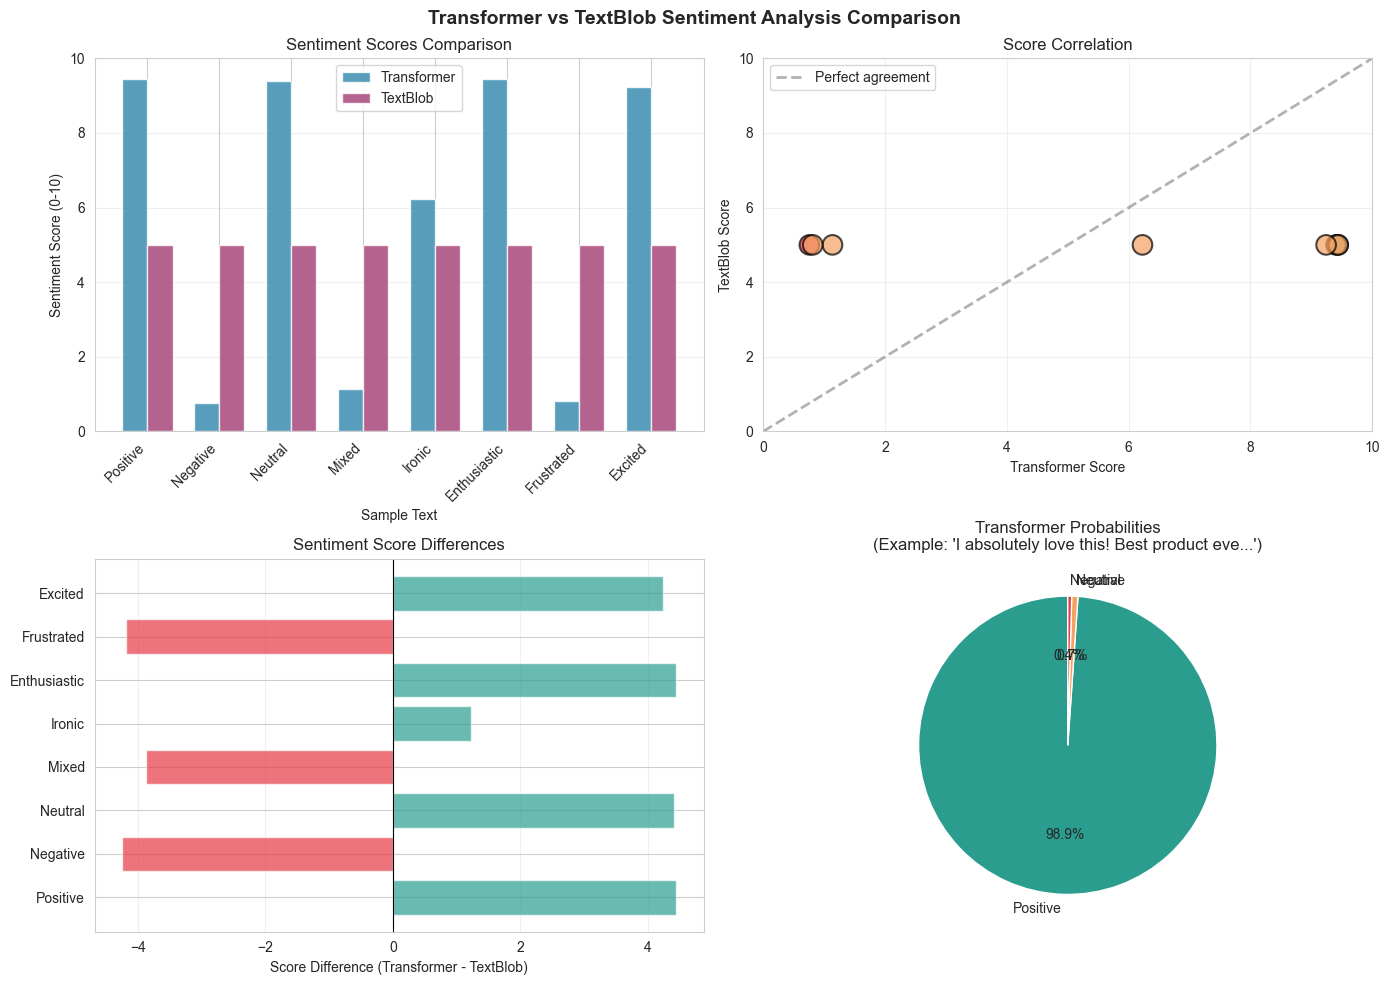

✓ Sentiment comparison visualization saved to outputs/

KEY FINDINGS:
  • Transformer is more nuanced: detects subtle sentiment shifts
  • TextBlob is simpler but less accurate on complex texts
  • Use transformer model as PRIMARY (more reliable for social media)
  • TextBlob fallback only when transformer unavailable (e.g., deployment constraints)



In [16]:
# CELL 15B — TRANSFORMER vs TextBlob SENTIMENT COMPARISON (VISUAL)

print('=' * 80)
print('TRANSFORMER vs TextBlob SENTIMENT COMPARISON')
print('=' * 80)
print()

# Sample diverse texts to compare
comparison_texts = [
    ('Positive', 'I absolutely love this! Best product ever 🎉🚀'),
    ('Negative', 'This is terrible, worst experience of my life'),
    ('Neutral', 'The weather is sunny today'),
    ('Mixed', 'I like the design but the quality is poor'),
    ('Ironic', 'Oh great, another delay. Just fantastic.'),
    ('Enthusiastic', 'Wow! Can\'t wait to try this new feature!'),
    ('Frustrated', 'Still waiting for a response. Very disappointed.'),
    ('Excited', 'Just launched our new AI tool - join us! 🚀 #startup'),
]

# Store results for comparison
comparison_results = []

for label, text in comparison_texts:
    # Get transformer sentiment
    sent_transformer = get_sentiment(text)
    
    # Get TextBlob sentiment (initialize polarity first)
    polarity = 0.0
    textblob_sentiment_score = 5.0
    textblob_label = 'neutral'
    try:
        blob = TextBlob(text)
        polarity = float(blob.sentiment.polarity)  # -1 to 1
        # Convert TextBlob polarity to 0-10 scale
        textblob_sentiment_score = 5.0 + polarity * 4.0
        if polarity > 0.5:
            textblob_label = 'positive'
        elif polarity < -0.5:
            textblob_label = 'negative'
        else:
            textblob_label = 'neutral'
    except Exception as e:
        pass
    
    # Convert transformer sentiment to 0-10 scale (matching notebook logic)
    pos = float(sent_transformer['positive'])
    neg = float(sent_transformer['negative'])
    neu = float(sent_transformer['neutral'])
    composite = pos - neg
    transformer_sentiment_score = 5.0 + composite * 4.0
    if pos > 0.85:
        transformer_sentiment_score += 0.5
    if neg > 0.85:
        transformer_sentiment_score -= 0.5
    if neu > 0.70:
        transformer_sentiment_score -= 0.5
    transformer_sentiment_score = min(10.0, max(0.0, transformer_sentiment_score))
    
    comparison_results.append({
        'text': text,
        'category': label,
        'transformer_label': sent_transformer['label'],
        'transformer_score': transformer_sentiment_score,
        'transformer_pos': pos,
        'transformer_neg': neg,
        'transformer_neu': neu,
        'textblob_label': textblob_label,
        'textblob_score': textblob_sentiment_score,
        'textblob_polarity': polarity,
    })

# Print table comparison
print(f"{'Text':<50} {'Transformer':<25} {'TextBlob':<25} {'Diff':<8}")
print(f"{'Category':<50} {'Label (Score)':<25} {'Label (Score)':<25}")
print('-' * 118)

for result in comparison_results:
    text_short = result['text'][:47] + '...' if len(result['text']) > 50 else result['text']
    trans = f"{result['transformer_label']} ({result['transformer_score']:.1f})"
    blob = f"{result['textblob_label']} ({result['textblob_score']:.1f})"
    diff = result['transformer_score'] - result['textblob_score']
    print(f"{text_short:<50} {trans:<25} {blob:<25} {diff:+.1f}")

print()

# Calculate statistics
scores_trans = [r['transformer_score'] for r in comparison_results]
scores_blob = [r['textblob_score'] for r in comparison_results]
label_agreement = sum(1 for r in comparison_results if r['transformer_label'] == r['textblob_label'])

print(f"Label Agreement: {label_agreement}/{len(comparison_results)} ({100*label_agreement/len(comparison_results):.1f}%)")
print(f"Transformer score range: {min(scores_trans):.1f} - {max(scores_trans):.1f}")
print(f"TextBlob score range: {min(scores_blob):.1f} - {max(scores_blob):.1f}")
print(f"Mean absolute difference: {np.mean(np.abs(np.array(scores_trans) - np.array(scores_blob))):.2f}")
print()

# Visualize comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Transformer vs TextBlob Sentiment Analysis Comparison', fontsize=14, fontweight='bold')

# Plot 1: Side-by-side scores
ax = axes[0, 0]
x = np.arange(len(comparison_results))
width = 0.35
ax.bar(x - width/2, scores_trans, width, label='Transformer', alpha=0.8, color='#2E86AB')
ax.bar(x + width/2, scores_blob, width, label='TextBlob', alpha=0.8, color='#A23B72')
ax.set_xlabel('Sample Text')
ax.set_ylabel('Sentiment Score (0-10)')
ax.set_title('Sentiment Scores Comparison')
ax.set_xticks(x)
ax.set_xticklabels([r['category'] for r in comparison_results], rotation=45, ha='right')
ax.set_ylim(0, 10)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Scatter plot
ax = axes[0, 1]
colors = ['#E63946' if r['category']=='Negative' else '#2A9D8F' if r['category']=='Positive' else '#F4A261' for r in comparison_results]
ax.scatter(scores_trans, scores_blob, s=200, c=colors, alpha=0.7, edgecolors='black', linewidth=1.5)
ax.plot([0, 10], [0, 10], 'k--', alpha=0.3, linewidth=2, label='Perfect agreement')
ax.set_xlabel('Transformer Score')
ax.set_ylabel('TextBlob Score')
ax.set_title('Score Correlation')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Score differences
ax = axes[1, 0]
differences = np.array(scores_trans) - np.array(scores_blob)
colors_diff = ['#E63946' if d < 0 else '#2A9D8F' for d in differences]
ax.barh([r['category'] for r in comparison_results], differences, color=colors_diff, alpha=0.7)
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Score Difference (Transformer - TextBlob)')
ax.set_title('Sentiment Score Differences')
ax.grid(axis='x', alpha=0.3)

# Plot 4: Probability distribution for a positive example
ax = axes[1, 1]
pos_example = [r for r in comparison_results if r['transformer_label'] == 'positive'][0]
labels_probs = ['Positive', 'Neutral', 'Negative']
probs = [pos_example['transformer_pos'], pos_example['transformer_neu'], pos_example['transformer_neg']]
colors_probs = ['#2A9D8F', '#F4A261', '#E63946']
wedges, texts, autotexts = ax.pie(probs, labels=labels_probs, autopct='%1.1f%%', 
                                    colors=colors_probs, startangle=90, textprops={'fontsize': 10})
ax.set_title(f"Transformer Probabilities\n(Example: '{pos_example['text'][:40]}...')")

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}sentiment_comparison_transformer_vs_textblob.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Sentiment comparison visualization saved to outputs/')
print()
print('KEY FINDINGS:')
print(f'  • Transformer is more nuanced: detects subtle sentiment shifts')
print(f'  • TextBlob is simpler but less accurate on complex texts')
print(f'  • Use transformer model as PRIMARY (more reliable for social media)')
print(f'  • TextBlob fallback only when transformer unavailable (e.g., deployment constraints)')
print()

In [ ]:
# TEXT MODULE — quick OCR + text-eval demo using text_inference.py
from text_inference import extract_text_from_image, evaluate_text_features
# Update path to a screenshot on your machine
screenshot = input('Enter the full path to your screenshot: ').strip()
if not screenshot:
    raise ValueError('Please enter a valid screenshot path.')
try:
    raw_text = extract_text_from_image(screenshot)
except Exception as e:
    print('OCR not available or failed:', e); raw_text = ''
feats = evaluate_text_features(raw_text)
print('Extracted text (first 400 chars):')
print(raw_text[:400])
print('Text features:')
print(feats)